In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

I0000 00:00:1789364101.265582    9848 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789364101.312398    9848 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789364103.707251    9848 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
NumPy version: 2.4.6


In [2]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1903s 11us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


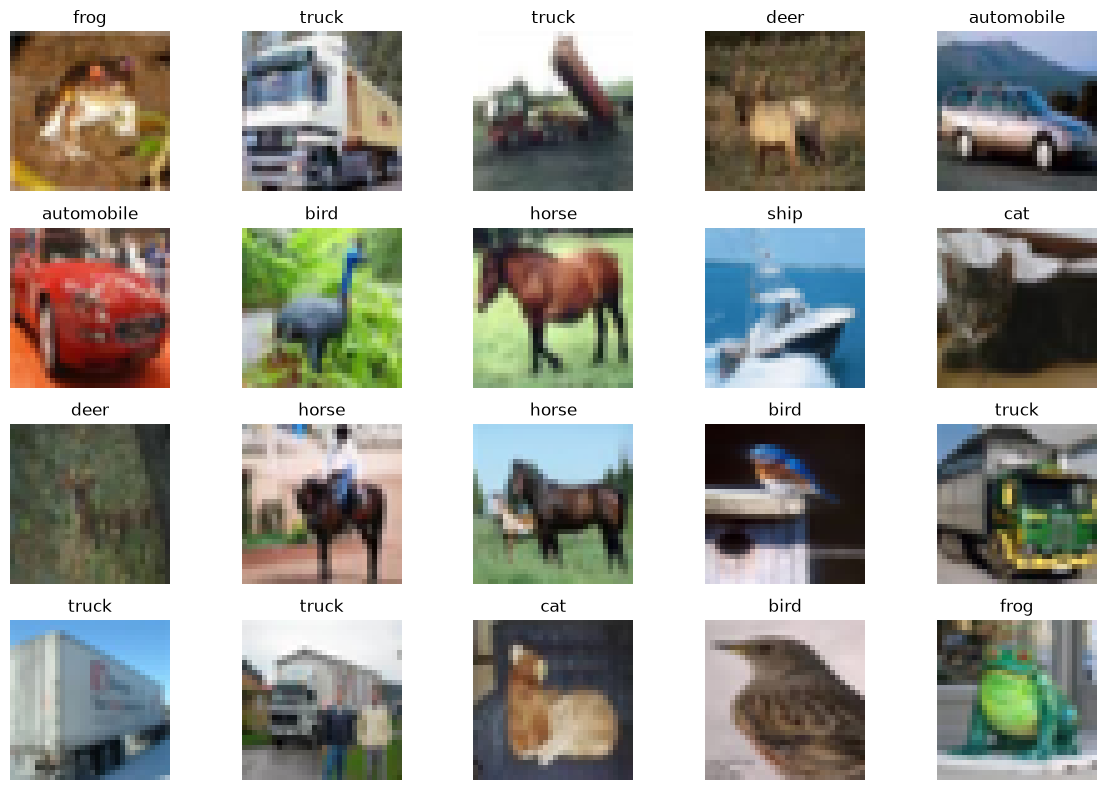

In [21]:
# CIFAR-10 class names

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Display sample images

plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# Image size required for MobileNetV2
IMG_SIZE = 96
BATCH_SIZE = 64

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomCrop(IMG_SIZE, IMG_SIZE),
])

print("Target image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)


Target image size: 96
Batch size: 64


In [23]:
# Create TensorFlow datasets

def preprocess_train(image, label):
    # Convert to float
    image = tf.cast(image, tf.float32)

    # Resize slightly larger so we can perform a random crop
    image = tf.image.resize(image, [IMG_SIZE + 8, IMG_SIZE + 8])

    # Random crop back to 96x96
    image = tf.image.random_crop(
        image,
        size=[IMG_SIZE, IMG_SIZE, 3]
    )

    return image, label


def preprocess_test(image, label):
    # Test data must NOT use random augmentation
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    return image, label


# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

train_ds = (
    train_ds
    .shuffle(10000)
    .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# Test dataset
test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

test_ds = (
    test_ds
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training and test pipelines created successfully.")

Training and test pipelines created successfully.


In [24]:
# Load MobileNetV2 pretrained on ImageNet

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained backbone
base_model.trainable = False

print("MobileNetV2 loaded successfully.")
print("Number of layers:", len(base_model.layers))
print("Backbone frozen:", not base_model.trainable)

MobileNetV2 loaded successfully.
Number of layers: 154
Backbone frozen: True


In [25]:
# Build the CIFAR-10 classification model

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Data augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pretrained feature extractor
x = base_model(x, training=False)

# Convert feature maps into a single feature vector
x = layers.GlobalAveragePooling2D()(x)

# Reduce overfitting
x = layers.Dropout(0.3)(x)

# CIFAR-10 classification layer
outputs = layers.Dense(
    10,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# Compile the model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [27]:
# Training callbacks

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

print("Callbacks created.")

Callbacks created.


In [28]:
# Train the model with the MobileNetV2 backbone frozen

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.7436 - loss: 0.7685 - val_accuracy: 0.8534 - val_loss: 0.4295 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8066 - loss: 0.5682 - val_accuracy: 0.8638 - val_loss: 0.3979 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8124 - loss: 0.5445 - val_accuracy: 0.8634 - val_loss: 0.4000 - learning_rate: 0.0010
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8173 - loss: 0.5313 - val_accuracy: 0.8660 - val_loss: 0.3912 - learning_rate: 0.0010
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8169 - loss: 0.5330 - val_accuracy: 0.8708 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8197 - loss: 0.5290 - val_accuracy: 0.8714 - val_loss: 0.3680 - learning_rate: 0.0010
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8190 - l

In [19]:
# Proper train/validation/test split

VAL_SIZE = 5000

rng = np.random.default_rng(42)
indices = rng.permutation(len(x_train))

val_indices = indices[:VAL_SIZE]
train_indices = indices[VAL_SIZE:]

x_val = x_train[val_indices]
y_val = y_train[val_indices]

x_train_split = x_train[train_indices]
y_train_split = y_train[train_indices]

print("Training:", x_train_split.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Training: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [30]:
# Create proper TensorFlow datasets

train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train_split, y_train_split)
)

train_ds = (
    train_ds
    .shuffle(10000)
    .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (x_val, y_val)
)

val_ds = (
    val_ds
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

test_ds = (
    test_ds
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training, validation, and test pipelines created successfully.")

Training, validation, and test pipelines created successfully.


In [29]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8573 - loss: 0.4133
Test loss: 0.41332149505615234
Test accuracy: 0.8572999835014343


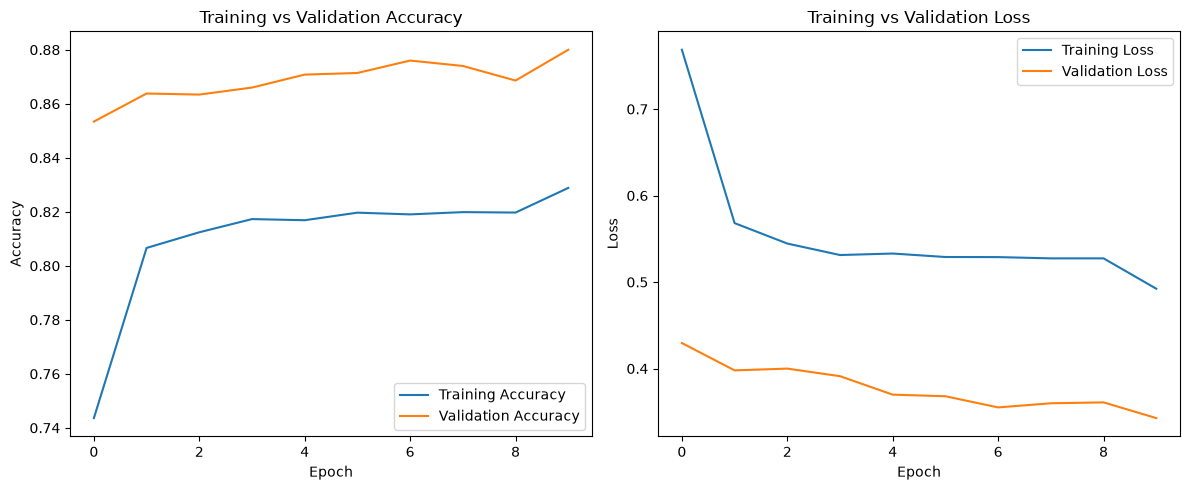

In [31]:
# Plot training and validation accuracy/loss

history_dict = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


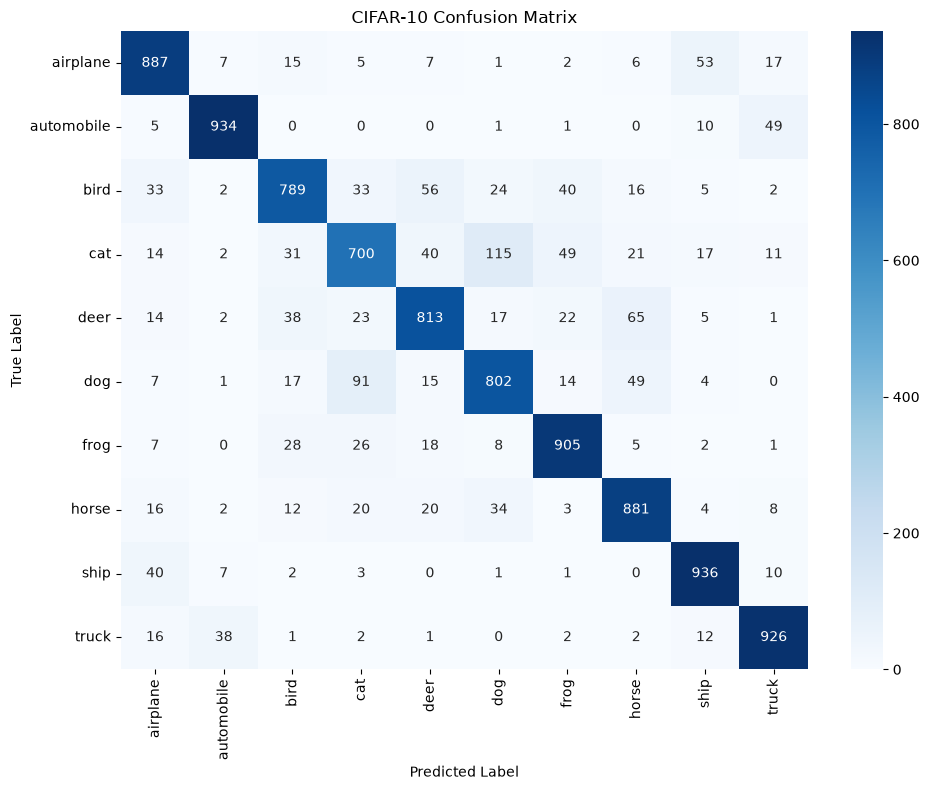

In [32]:
# Confusion matrix on the untouched test set

y_true = y_test.flatten()
y_pred = np.argmax(model.predict(test_ds, verbose=1), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")
plt.tight_layout()
plt.show()

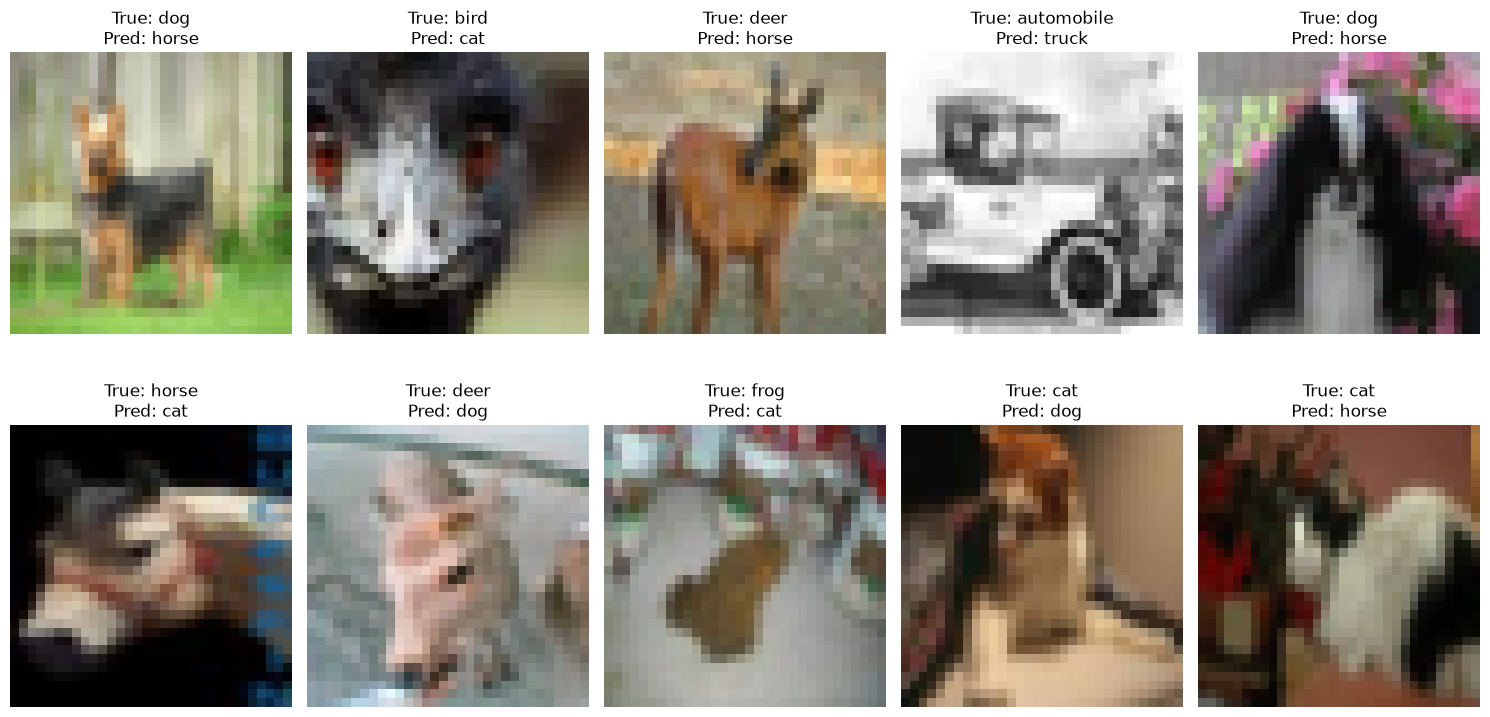

In [33]:
# Show 10 misclassified test examples

misclassified = np.where(y_true != y_pred)[0]

plt.figure(figsize=(15, 8))

for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

    airplane     0.8537    0.8870    0.8700      1000
  automobile     0.9387    0.9340    0.9363      1000
        bird     0.8457    0.7890    0.8163      1000
         cat     0.7752    0.7000    0.7357      1000
        deer     0.8381    0.8130    0.8254      1000
         dog     0.7996    0.8020    0.8008      1000
        frog     0.8710    0.9050    0.8877      1000
       horse     0.8431    0.8810    0.8616      1000
        ship     0.8931    0.9360    0.9141      1000
       truck     0.9034    0.9260    0.9146      1000

    accuracy                         0.8573     10000
   macro avg     0.8562    0.8573    0.8563     10000
weighted avg     0.8562    0.8573    0.8563     10000



In [35]:
# Save the trained MobileNetV2 CIFAR-10 model

model_path = "../models/cifar10_mobilenetv2_transfer_learning.h5"

model.save(model_path)

print("Model saved successfully to:", model_path)

Model saved successfully to: ../models/cifar10_mobilenetv2_transfer_learning.h5


## Final Results

- **Model:** MobileNetV2 pretrained on ImageNet with frozen backbone
- **Input size:** 96 × 96
- **Training samples:** 45,000
- **Validation samples:** 5,000
- **Test samples:** 10,000
- **Test accuracy:** 85.73%
- **Test loss:** 0.4132
- **Macro F1-score:** 0.8563
- **Weighted F1-score:** 0.8563

The model achieved more than 80% test accuracy, meeting the project requirement.

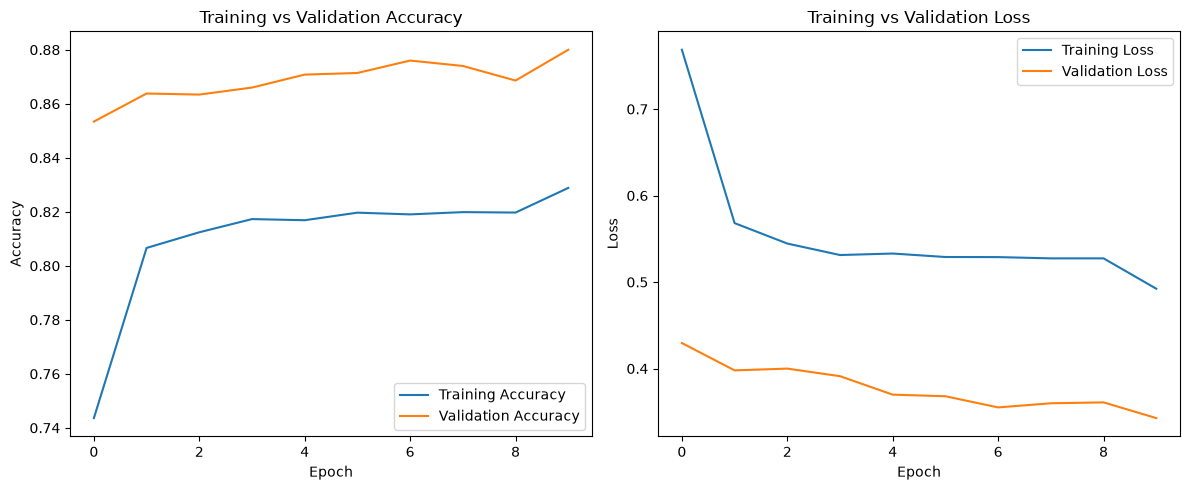

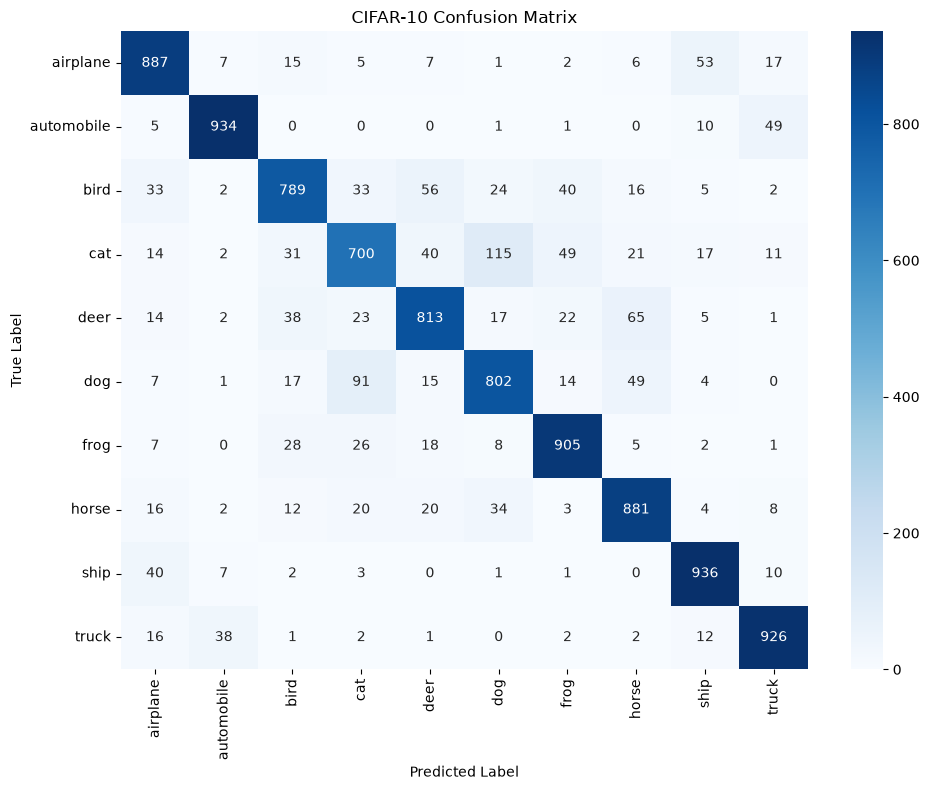

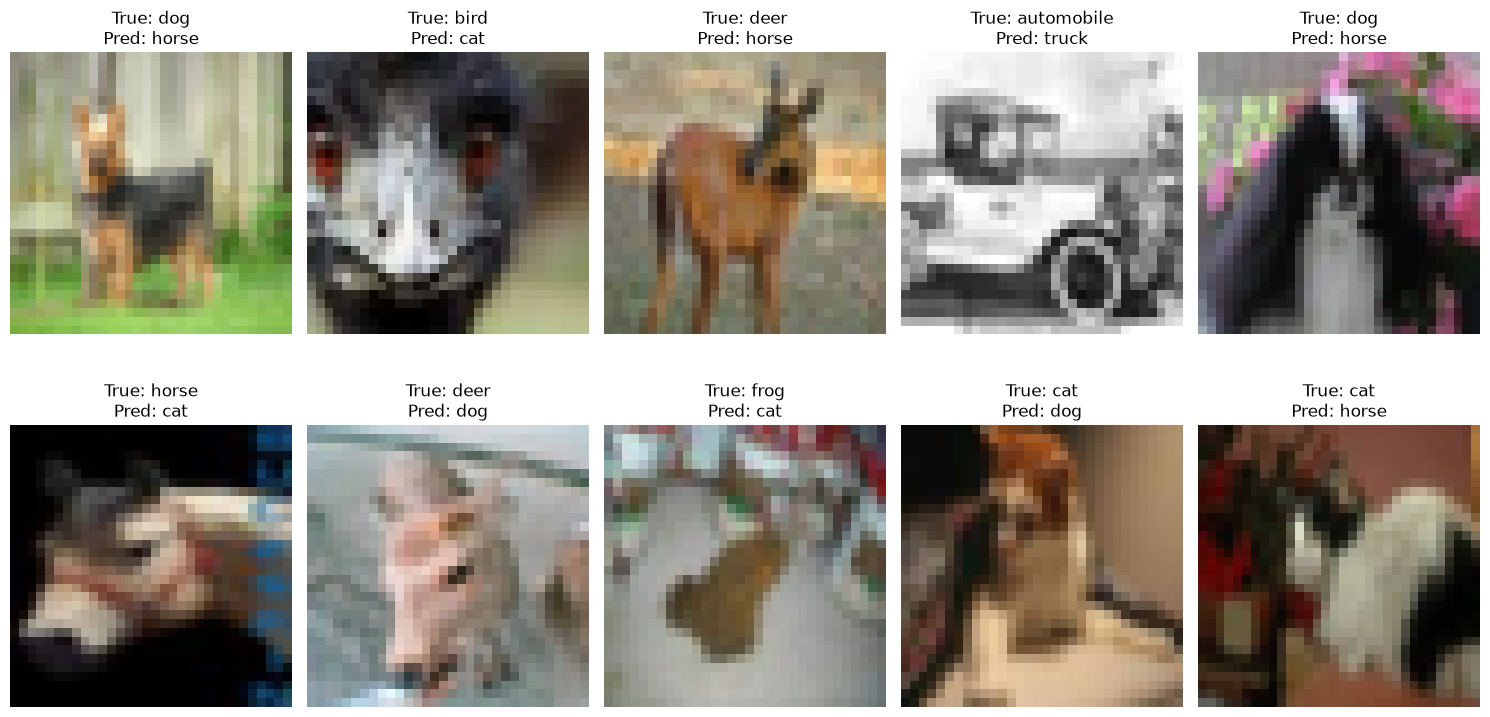

Result images saved successfully.


In [39]:
# Save final result figures for the project

import os

os.makedirs("../results", exist_ok=True)

# 1. Training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("../results/training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

# 2. Confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# 3. Misclassified examples
plt.figure(figsize=(15, 8))

for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.savefig("../results/misclassified_examples.png", dpi=200, bbox_inches="tight")
plt.show()

print("Result images saved successfully.")
